In [1]:
using Pkg
Pkg.activate("..")   # activate project environment

using Plots
using LaTeXStrings

using NPZ # for numpy-compatible file reading and writing

using DataFrames
using GLM # for linear regression

using Revise # automatically sync src updates
using SkyrmionTunnelling
const ST = SkyrmionTunnelling # alias for easier coding

  Activating project at `~/Documents/GitHub/skyrmion-tunnelling`
[ Info: Precompiling SkyrmionTunnelling [51d433a5-d9a2-4638-a6de-06b0503db32e] (cache misses: include_dependency fsize change (2))


SkyrmionTunnelling

In [2]:
function analyse_power_law(x,y;xlabel=L"(R/a)",ylabel="y", title="", digits=2)
    data = DataFrame( X=log.(x), Y=log.(y) )
    model = lm(@formula(Y ~ X), data)
    coef(model) #intercept, slope

    P = plot(xlabel=xlabel, ylabel=ylabel, title = title)
    
    # show numerical data
    scatter!(P, x, y, label="numerical results", ylims=pretty_y_limits(y))

    # show the approximate relation
    a = exp(coef(model)[1])
    b = coef(model)[2]
    label_string = ylabel * " = $(round(a,digits=digits)) * " * xlabel * "^$(round(b,digits=digits))"
    x_range = LinRange(0.0, maximum(x), 100)
    plot!(P, x_range, a*x_range.^b, label = label_string, ls=:dash)

    # add a y=0 line passing through the origin (which is a special point for power laws and thus should be included)
    plot!(P, [0,length_scale[end]], [0,0], ls=:solid, label=false, colour=:grey)

    display(P)
    return a,b
end

function fit_power_law(x,y;power, xlabel=L"(R/a)",ylabel="y", title="", digits=2)
    data = DataFrame( X=x .^power, Y=real.(y) )
    model = lm(@formula(Y ~ 0 + X), data)
    coef(model) #intercept, slope

    P = plot(xlabel=xlabel, ylabel=ylabel, title = title)
    
    # show numerical data
    scatter!(P, x, y, label="numerical results", ylims=pretty_y_limits(y))

    # show the approximate relation
    a = coef(model)[1]
    label_string = ylabel * " = $(round(a,digits=digits)) * " * xlabel * "^$(round(power,digits=digits))"
    x_range = LinRange(0.0, maximum(x), 100)
    plot!(P, x_range, a*x_range.^power, label = label_string, ls=:dash)

    # add a y=0 line passing through the origin (which is a special point for power laws and thus should be included)
    plot!(P, [0,length_scale[end]], [0,0], ls=:solid, label=false, colour=:grey)

    display(P)
    return a
end


function pretty_y_limits(y)
    max_y = maximum(y)
    margin_fraction = 0.05
    return (-margin_fraction*max_y, (1+margin_fraction)*max_y)
end

pretty_y_limits (generic function with 1 method)

# Double well plot

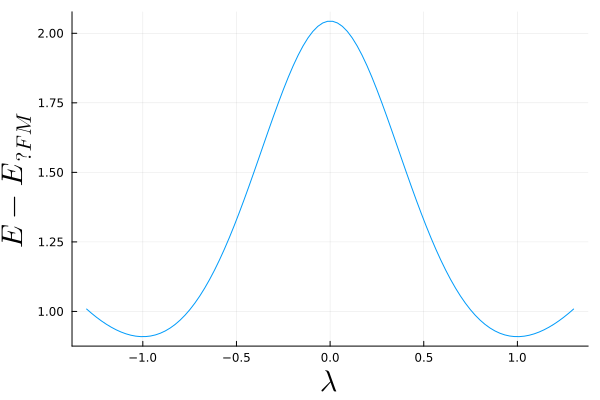

In [3]:
n = npzread("../data/k01b06/l100.npy")
system = microscopic_system(length_scale=1.0, k=0.1, b=0.6, n_sites=n.size[2])
coord = LambdaCoordinate(ST.w_project(n))

show_double_well(system, coord, xmin=-1.3, xmax=1.3)

In [297]:
savefig("Images/double_well_lambda.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/double_well_lambda.png"

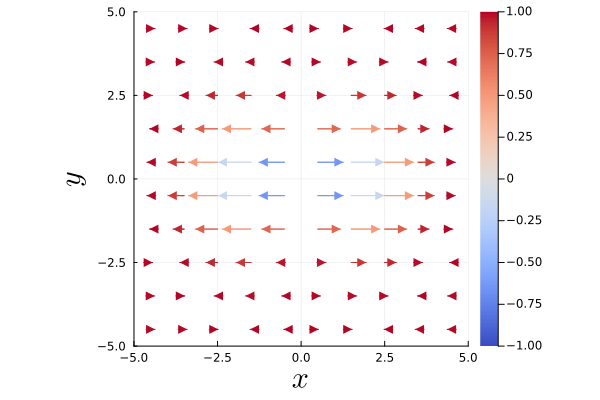

In [23]:
n_lambda = ST.n_collective(0, system.lattice, coord)
in_plane_quiver(n_lambda, system.lattice)

Imaginary part = 1.030609270453252e-8
Imaginary part = 2.68522544793954e-5
WARNING ----> imaginary part is non-zero !!!!! ---------> It gets neglected via a real projection
The saddle point is at 1.0000000049707647 + 1.098714187406228e-14im
The instantonic trajectory passes through the point 
 x = 1.0041618286084917

Progress:  14%|█████▌                                   |  ETA: 0:00:01

 - 7.625068489340557e-11im
 y = 0.9000863620868922 + 1.1570531788655118e-12im
sanity check : |H_inst-H0| = 1.1937117962059285e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress:  25%|██████████▍                              |  ETA: 0:00:00

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


imaginary = 1.3032071747533257e-7

Total action = 40.85447569972346 + 6.10751676731503e-8im


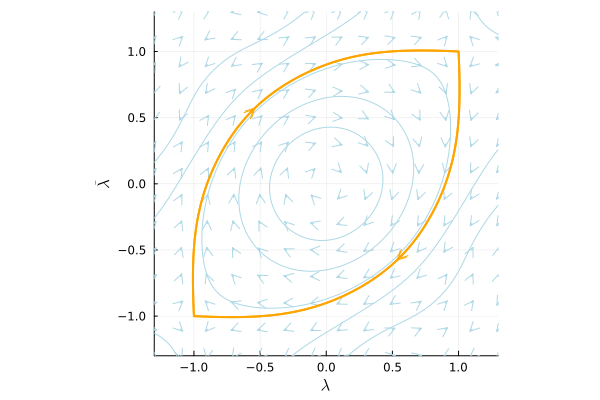

In [298]:
ST.show_phase_portrait(system,coord,xmin=-1.3, xmax=1.3, levels=5)

In [299]:
savefig("Images/lambda_phase_portrait.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/lambda_phase_portrait.png"

In [308]:
function distance_squared(x1,y1,x2,y2)
    return abs2(x1-x2)+abs2(y1-y2)
end

function show_instanton(sol; dt=0.02, epsilon=0.01)
    centre = argmin( abs2.(sol[1,:]+sol[2,:]) )

    i = centre
    while distance_squared(sol[1,i],sol[2,i], 1,1) > epsilon^2
        i = i-1
    end

    j = centre
    while distance_squared(sol[1,j],sol[2,j], -1,-1) > epsilon^2
        j = j+1
    end
    println("i = $i, \t, j=$j")
    T = dt*(j-i)
    t = LinRange(-T/2, T/2, j-i+1)

    P = plot(xlabel=L"\tau")
    plot!(P, t, real.(sol[1,i:1:j]), label=L"\lambda")
    plot!(P, t, real.(sol[2,i:1:j]), label=L"\bar{\lambda}")
    return P
end

show_instanton (generic function with 1 method)

The saddle point is at 1.0000000049707647 + 1.098714187406228e-14im
The instantonic trajectory passes through the point 
 x = 1.002236331086129

Progress:  26%|██████████▊                              |  ETA: 0:00:01

 - 3.410044982349269e-11im
 y = 0.9500499073314336 + 3.0991713002585586e-13im
sanity check : |H_inst-H0| = 2.8421709430516416e-12
-- Integrating forwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00
Progress:  20%|████████▎                                |  ETA: 0:00:00

-- Integrating backwards -- 


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


imaginary = 8.62874026188472e-9


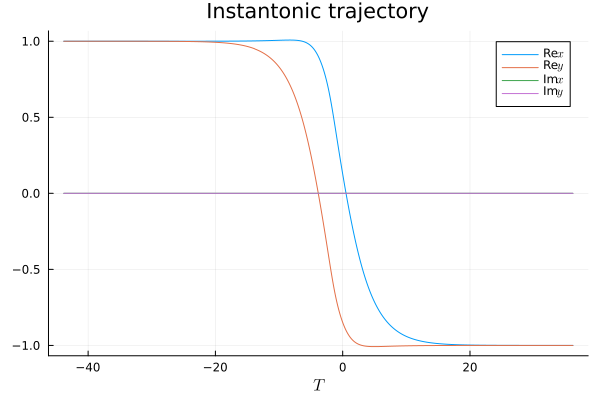

imaginary = 8.62874026188472e-9


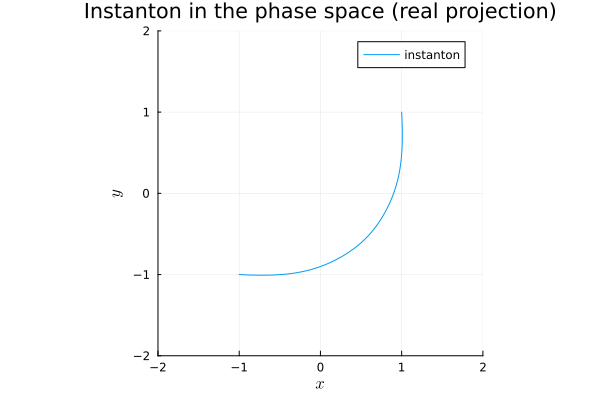


Total action = 20.44957231881404 - 1.9215164025488696e-7im


(20.44957231881404 - 1.9215164025488696e-7im, ComplexF64[1.0000003850443056 - 5.9009062415556815e-12im 1.0000003914971785 - 5.787325355127284e-12im … -0.9999866052268708 + 9.971352313379108e-13im -0.9999868287812 + 9.976018201991117e-13im; 0.9999971099381038 - 9.116473869936578e-13im 0.9999970553502011 - 9.170522278068683e-13im … -0.9999989711594208 + 1.0842831585636182e-12im -0.9999989257137554 + 1.1214931894450887e-12im])

In [309]:
S_inst, sol = instanton(system,coord,x_init=1.0, direction_guess=[0,-0.05],T_backward=30, T_forward=50, dt=0.05)

i = 500, 	, j=1189


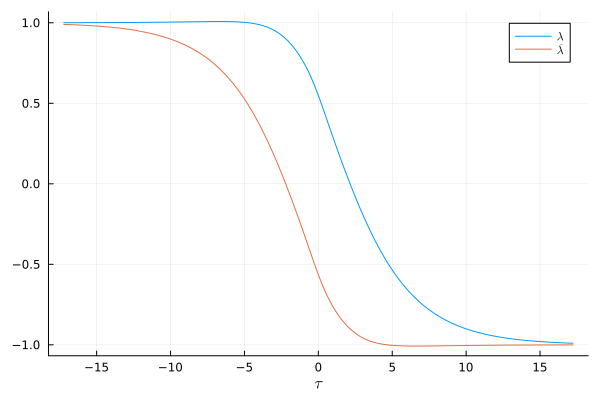

In [310]:
show_instanton(sol, dt=0.05)

In [311]:
savefig("Images/instanton_in_time.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/instanton_in_time.png"

# The continuum limit

In [251]:
function b_to_string(b)
    zero = (b<1) ? "0" : ""
    return zero*string(Int(10*b))
end
b_to_string(1.2)

"12"

### Skyrmion profiles comparison

In [279]:
function show_profile!(P, n, system; scale_down_factor=1)
    X,Y = XY_meshgrid(system.lattice)
    R = sqrt.(X .^2 + Y .^2)
    scatter!(P, vec(R/scale_down_factor), vec(acos.(n[3,:,:])))
end    

show_profile! (generic function with 1 method)

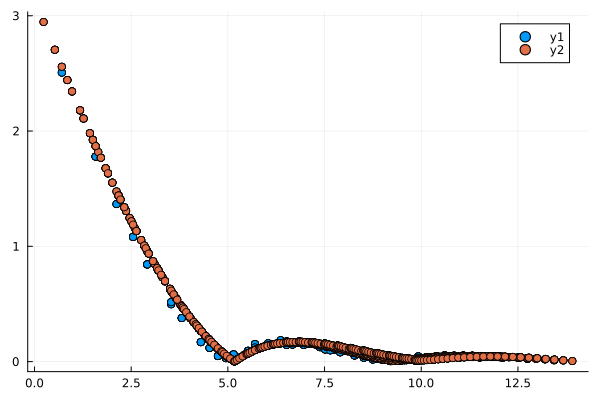

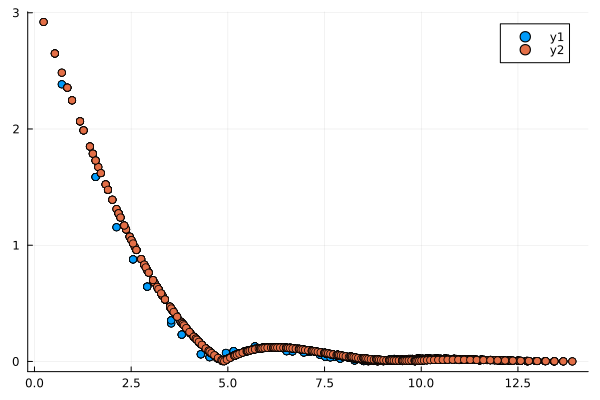

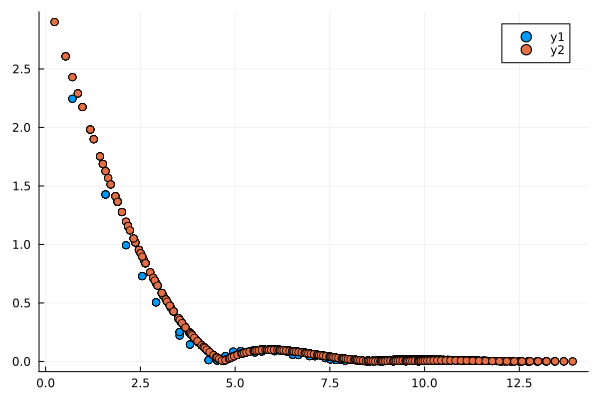

In [281]:
for b in [0.6, 0.9, 1.2]
    P = plot()
    for i = 100:200:300
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])

        show_profile!(P, n, system, scale_down_factor=l)
    end
    display(P)
end

## Actions

In [252]:
S_list = []
for b in [0.6, 0.9, 1.2]
    S = []
    for i = 100:50:500
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
        sol = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
        coord = LambdaCoordinate(ST.w_project(n))
        push!( S, ST.action(system,coord,sol,dt=1.0, show=false) )
    end
    push!(S_list, S)
end


Total action = 20.450023263880485 - 1.8676262666529116e-7im

Total action = 53.84448900589747 + 5.094087610795318e-7im

Total action = 97.56840951704494 + 8.197302825038813e-8im

Total action = 151.0638093999787 - 6.249003251073661e-7im

Total action = 216.37124067221075 + 3.559115531848797e-7im

Total action = 294.7791798420128 - 3.9500529158990673e-7im

Total action = 383.15151786270997 - 8.621126134406923e-8im

Total action = 479.6270568853621 - 9.384609348669883e-9im

Total action = 587.1210405660429 - 3.6541020503538733e-7im

Total action = 12.510979843722257 - 6.088563745919258e-8im

Total action = 42.91170897437624 + 4.799498811012438e-6im

Total action = 78.94889192421209 + 6.47547778922354e-8im

Total action = 123.05598429785044 + 5.82972062200627e-7im

Total action = 177.08290937876188 - 4.825660254784807e-7im

Total action = 239.94905577640188 - 1.068747780975019e-8im

Total action = 310.86086664876666 - 4.3420291326633865e-7im

Total action = 393.4921433721931 - 6.46076874

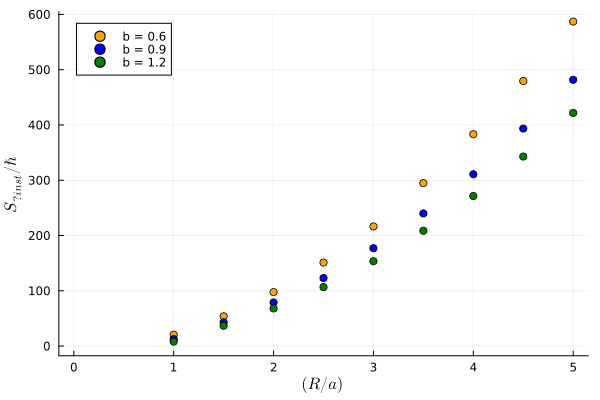

In [253]:
length_scale = [i/100 for i=100:50:500]
P = plot(xlabel=L"(R/a)", ylabel=L"S_{\text{inst}}/\hbar")
colour = [:orange, :blue, :green]
scatter!(P, length_scale, real.(S_list[1]), label="b = 0.6", colour=colour[1])
scatter!(P, length_scale, real.(S_list[2]), label="b = 0.9", colour=colour[2])
scatter!(P, length_scale, real.(S_list[3]), label="b = 1.2", colour=colour[3])
plot!(P, [0], [0], label=false)

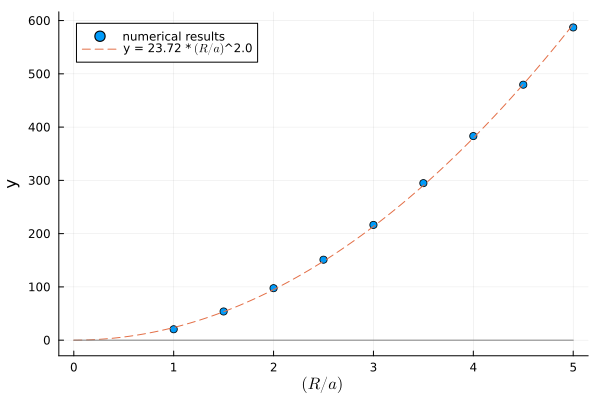

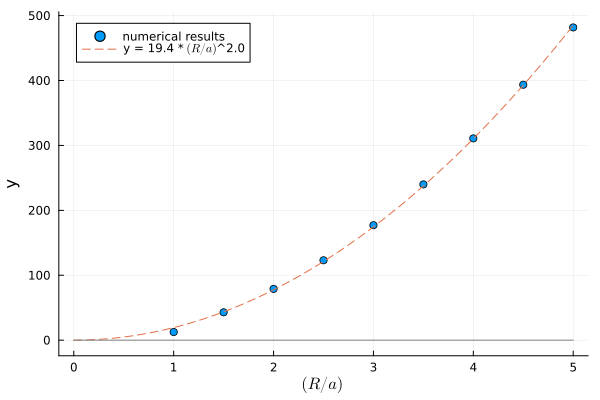

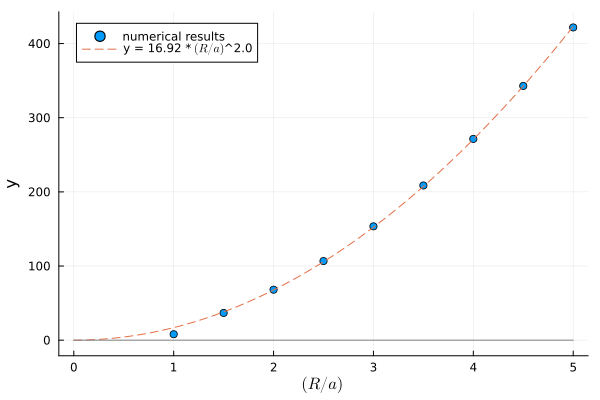

In [254]:
prefactor = []
for i=1:3
    push!(prefactor,fit_power_law(length_scale, real.(S_list[i]), power=2))
end

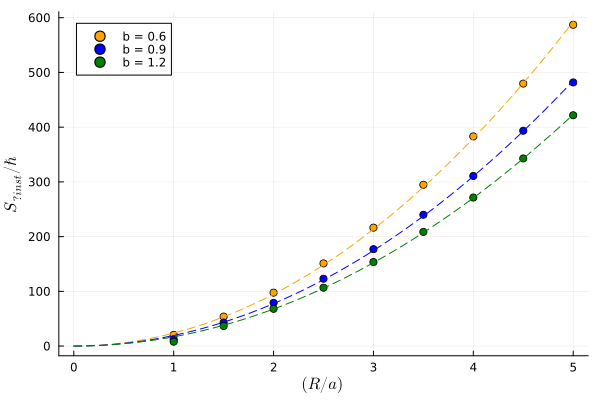

In [255]:
l_range = LinRange(0,5,100)
for i=1:3
    plot!(P, l_range, prefactor[i]*l_range.^2, label=false, colour=colour[i], ls=:dash)
end
P

In [256]:
savefig("Images/S_scaling.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/S_scaling.png"

## Skyrmion energy

In [257]:
Delta_E_list = []
for b in [0.6, 0.9, 1.2]
    Delta_E = []
    for i = 100:50:500
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
        sol = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
        coord = LambdaCoordinate(ST.w_project(n))

        push!( Delta_E, H(1,1, system, coord))
    end
    push!(Delta_E_list, Delta_E)
end

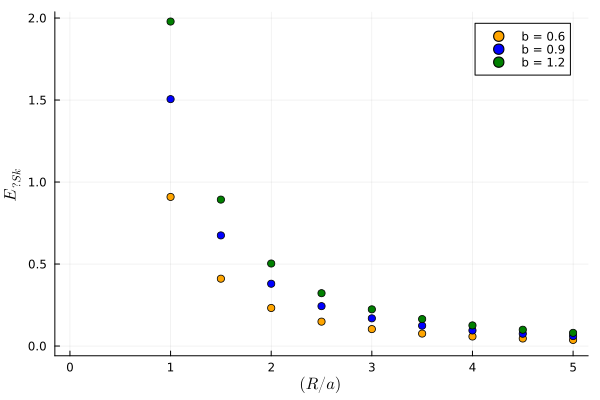

In [258]:
length_scale = [i/100 for i=100:50:500]
Q = plot(xlabel=L"(R/a)", ylabel=L"E_{\text{Sk}}")
colour = [:orange, :blue, :green]
scatter!(Q, length_scale, real.(Delta_E_list[1]), label="b = 0.6", colour=colour[1])
scatter!(Q, length_scale, real.(Delta_E_list[2]), label="b = 0.9", colour=colour[2])
scatter!(Q, length_scale, real.(Delta_E_list[3]), label="b = 1.2", colour=colour[3])
plot!(Q, [0], [0], label=false)

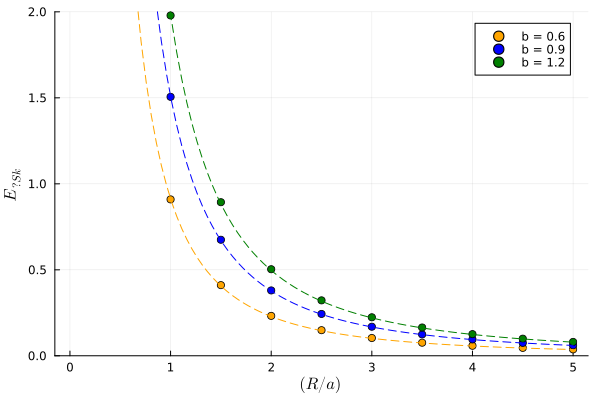

In [259]:
prefactor = []
for i=1:3
    push!(prefactor,fit_power_law(length_scale, real.(Delta_E_list[i]), power=-2))
end
IJulia.clear_output()
l_range = LinRange(0,5,100)
for i=1:3
    plot!(Q, l_range, prefactor[i]*l_range.^(-2), label=false, colour=colour[i], ls=:dash, ylims=(0,2.0))
end
Q

## Barrier Height

In [260]:
Delta_E_list = []
for b in [0.6, 0.9, 1.2]
    Delta_E = []
    for i = 100:50:500
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
        sol = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
        coord = LambdaCoordinate(ST.w_project(n))

        push!( Delta_E, H(0,0, system, coord) - H(1,1, system, coord))
    end
    push!(Delta_E_list, Delta_E)
end

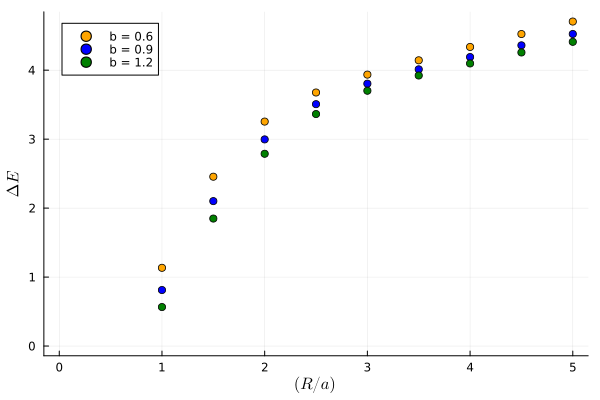

In [261]:
length_scale = [i/100 for i=100:50:500]
R = plot(xlabel=L"(R/a)", ylabel=L"\Delta E")
colour = [:orange, :blue, :green]
scatter!(R, length_scale, real.(Delta_E_list[1]), label="b = 0.6", colour=colour[1])
scatter!(R, length_scale, real.(Delta_E_list[2]), label="b = 0.9", colour=colour[2])
scatter!(R, length_scale, real.(Delta_E_list[3]), label="b = 1.2", colour=colour[3])
plot!(R, [0], [0], label=false)

## Skyrmion size 

In [262]:
size_list = []
for b in [0.6, 0.9, 1.2]
    size = []
    for i = 100:50:500
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
        sol = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
        coord = LambdaCoordinate(ST.w_project(n))

        push!( size, ST.skyrmion_area(n))
    end
    push!(size_list, size)
end

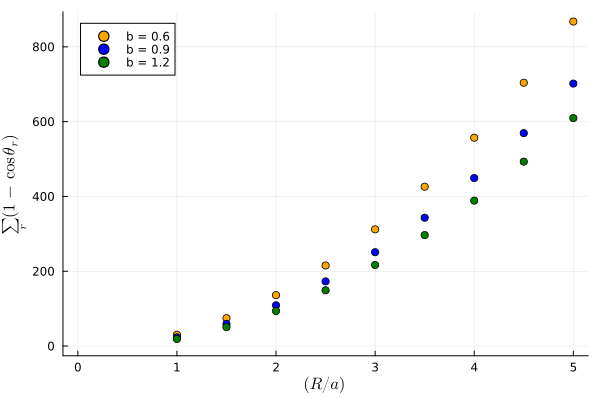

In [263]:
length_scale = [i/100 for i=100:50:500]
S = plot(xlabel=L"(R/a)", ylabel=L"\sum_r (1-\cos \theta_r)")
colour = [:orange, :blue, :green]
scatter!(S, length_scale, real.(size_list[1]), label="b = 0.6", colour=colour[1])
scatter!(S, length_scale, real.(size_list[2]), label="b = 0.9", colour=colour[2])
scatter!(S, length_scale, real.(size_list[3]), label="b = 1.2", colour=colour[3])
plot!(S, [0], [0], label=false)

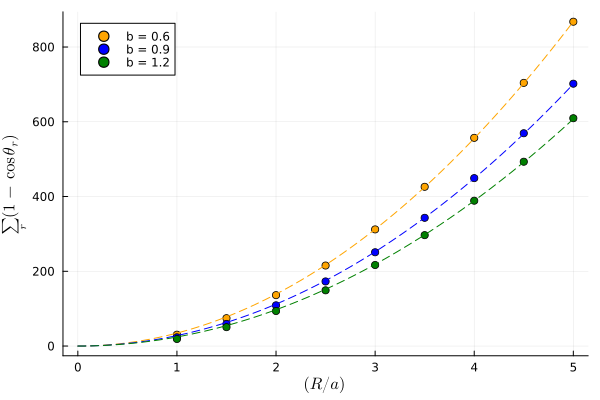

In [264]:
prefactor = []
for i=1:3
    push!(prefactor,fit_power_law(length_scale, real.(size_list[i]), power=2))
end
IJulia.clear_output()
l_range = LinRange(0,5,100)
for i=1:3
    plot!(S, l_range, prefactor[i]*l_range.^(2), label=false, colour=colour[i], ls=:dash)
end
S

## Instanton frequency

In [201]:
function omega(system::System, coord::CollectiveCoordinate)
    # find a point through which the instanton passes (copied from the instanton routine)
    x_min = ST.find_saddle(system,  coord, initial_guess = 1.0)
    direction_guess = [0.0, -0.01] # the radius should be small
    x0, y0 = ST.find_similar_energy(x_min, conj(x_min), system, coord, x_init = x_min+direction_guess[1], y_init=x_min+direction_guess[2])

    u0 = [x0,y0]

    v = ST.v(u0[1],u0[2],system,coord)
    norm_v = sqrt(abs2(v[1])+abs2(v[2]))
    println(norm_v)
    # v*dt < epsilon, so dt < epsilon / v
    dt = 1e-6 / norm_v
    T = 100*dt
    println("dt = ", dt)
    s = solve_ivp(u0,system,coord, dt=-dt, T=T)
    d = sqrt.( abs2.(s[1,:] .-1) + abs2.(s[2,:] .-1) )
    log_d = log.(d)
    P = plot(log_d)
    display(P)
    return (log_d[1]-log_d[end]) / T
end

omega (generic function with 2 methods)

0.0031996874839002034
dt = 0.00031253052213120117


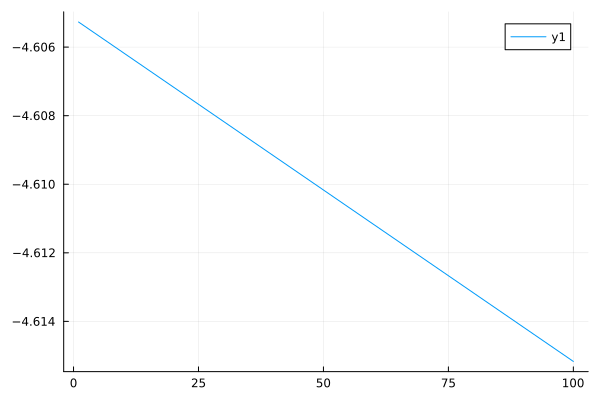

0.001171345988491685


Progress:  61%|█████████████████████████                |  ETA: 0:00:00

dt = 0.000853718721731123


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


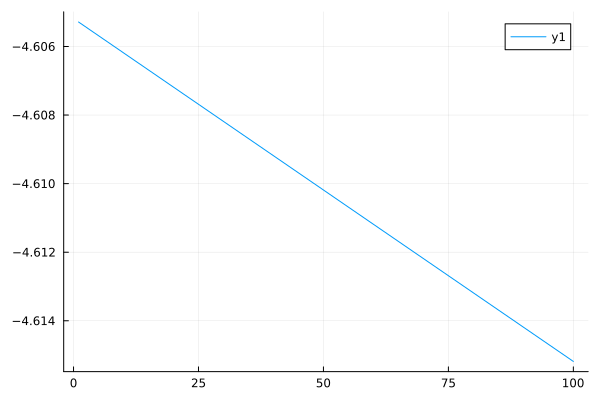

0.0005093063763313609


Progress:  35%|██████████████▍                          |  ETA: 0:00:00

dt = 0.0019634547032440605


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


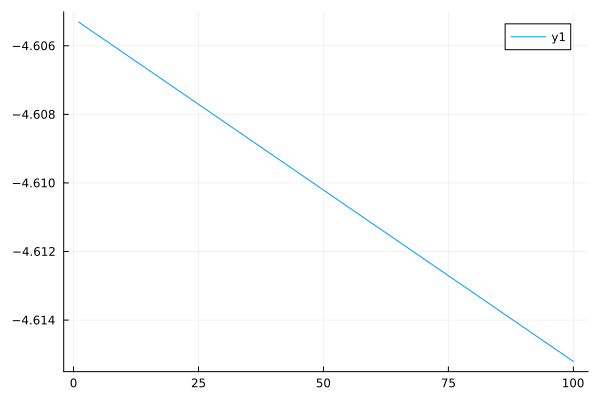

0.00025692785093676083


Progress:  23%|█████████▍                               |  ETA: 0:00:00

dt = 0.0038921432470399478


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


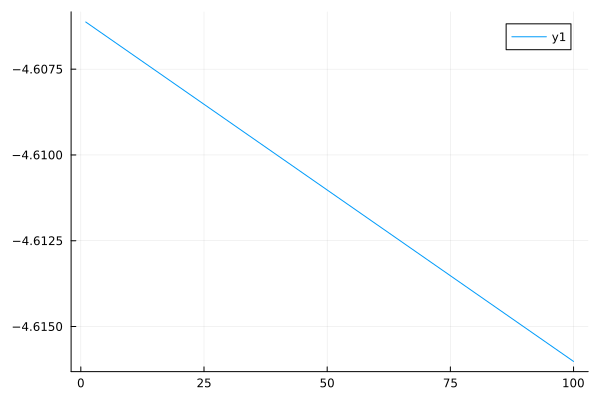

0.00014347963414237691


Progress:  16%|██████▌                                  |  ETA: 0:00:01

dt = 0.0069696302613072286


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


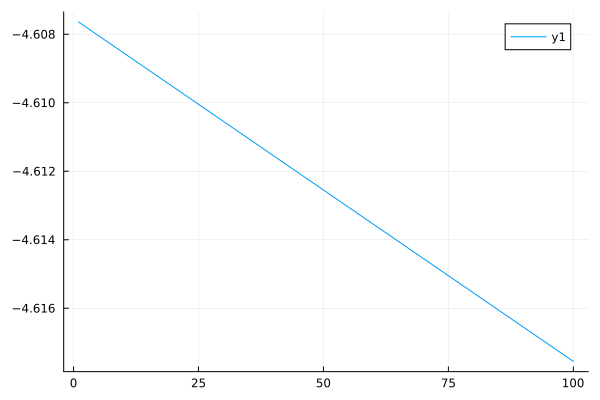

8.691393852782924e-5


Progress:  12%|████▉                                    |  ETA: 0:00:01

dt = 0.011505634388893871


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


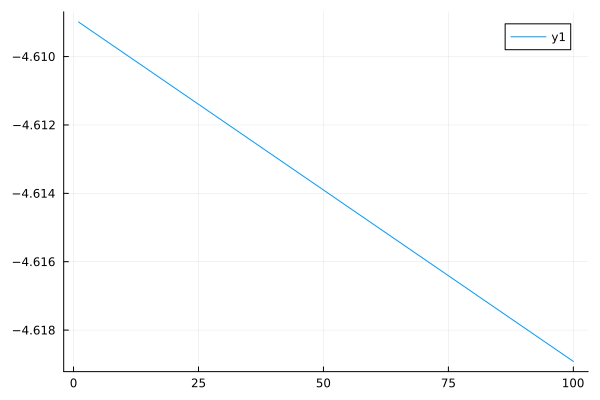

5.578868423350081e-5


Progress:  10%|████▏                                    |  ETA: 0:00:01

dt = 0.017924781947079964


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


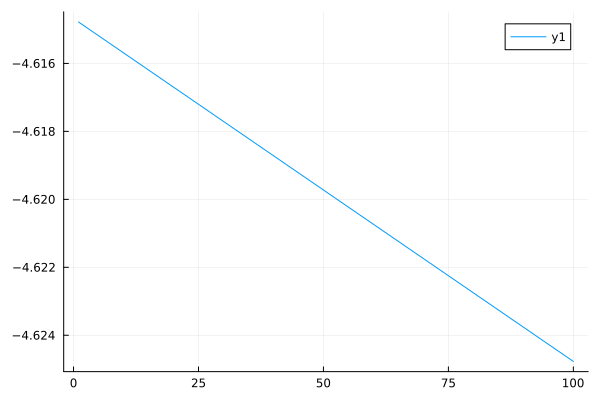

3.7852156152186053e-5


Progress:   7%|██▉                                      |  ETA: 0:00:01

dt = 0.026418574307351513


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


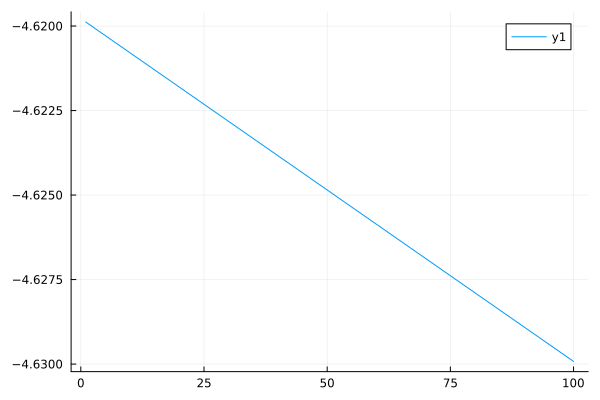

2.6575663793403103e-5


Progress:   6%|██▌                                      |  ETA: 0:00:02

dt = 0.03762841100692396


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


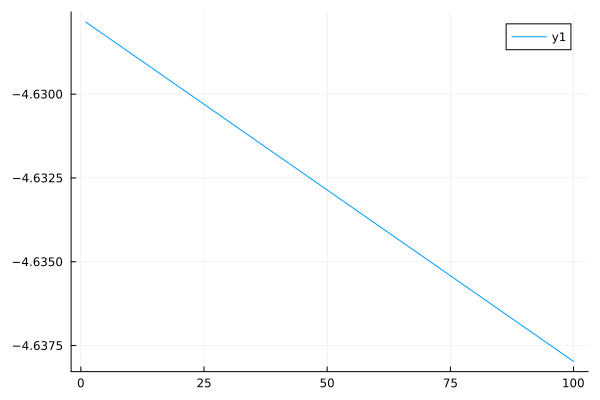

0.004071883484094886
dt = 0.000245586594976522


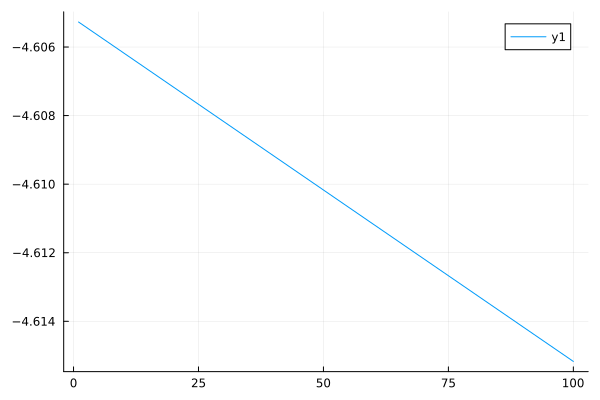

0.0016150420337387081


Progress:  59%|████████████████████████▎                |  ETA: 0:00:00

dt = 0.0006191789310183281


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


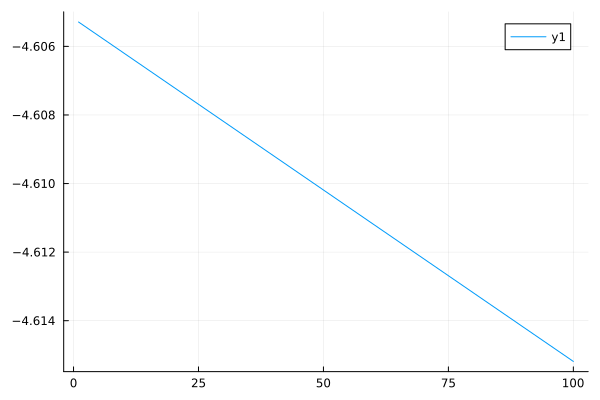

0.0007246244450827836


Progress:  35%|██████████████▍                          |  ETA: 0:00:00

dt = 0.0013800252072447771


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


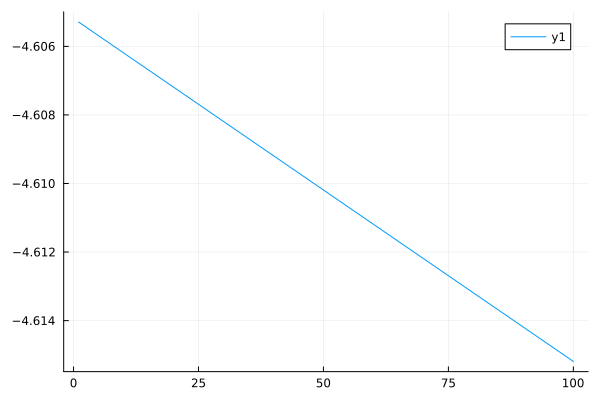

0.0003717847477985525


Progress:  23%|█████████▍                               |  ETA: 0:00:00

dt = 0.0026897284138773735


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


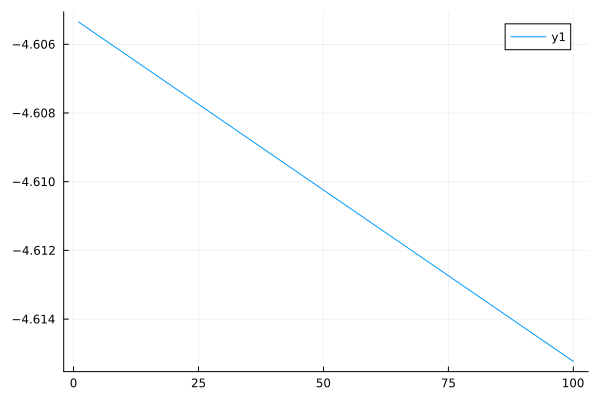

0.00020968533381903278


Progress:  15%|██████▏                                  |  ETA: 0:00:01

dt = 0.0047690507570884375


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


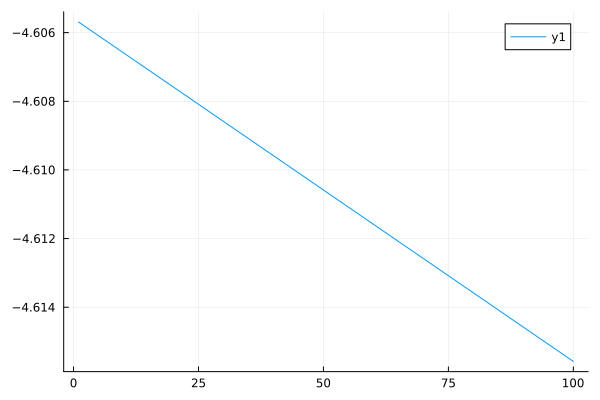

0.00012749073046871353


Progress:  12%|████▉                                    |  ETA: 0:00:01

dt = 0.007843707509742458


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


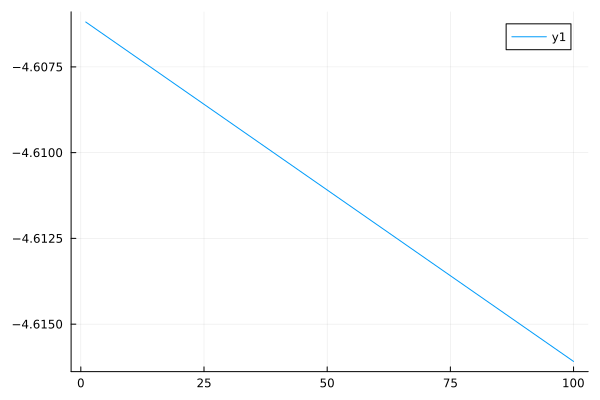

8.23279791644037e-5


Progress:  10%|████▏                                    |  ETA: 0:00:01

dt = 0.012146538882037466


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


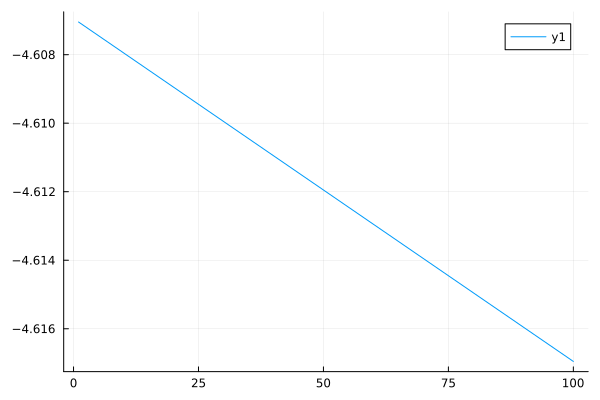

5.5664855301243615e-5


Progress:   7%|██▉                                      |  ETA: 0:00:01

dt = 0.01796465641720008


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


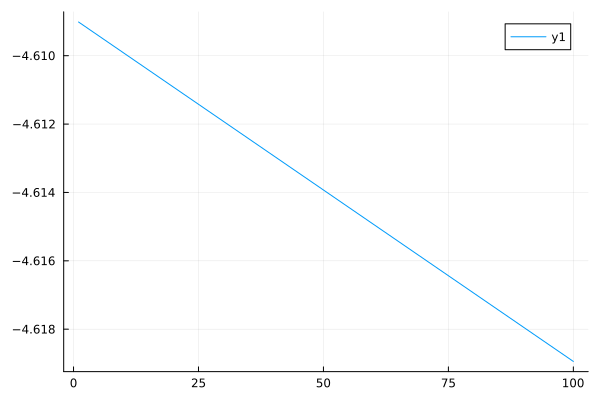

3.923746660874872e-5


Progress:   6%|██▌                                      |  ETA: 0:00:02

dt = 0.025485845199216595


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


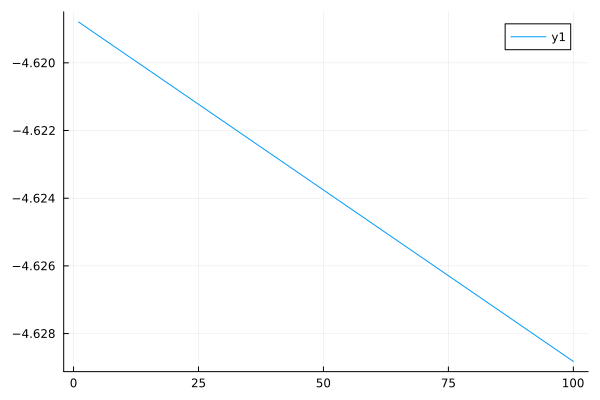

0.004639087823979534
dt = 0.0002155596181712665


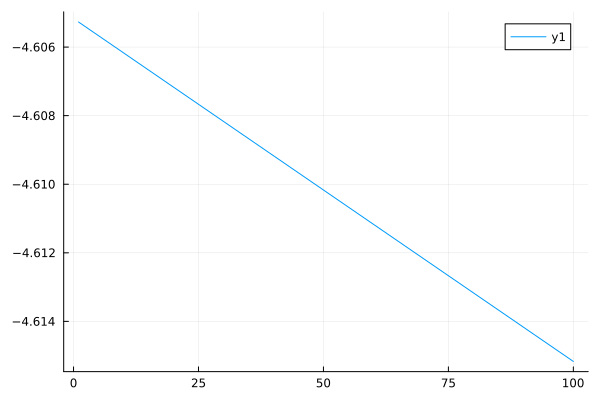

0.001971099874001145


Progress:  63%|█████████████████████████▉               |  ETA: 0:00:00

dt = 0.0005073309643970984


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


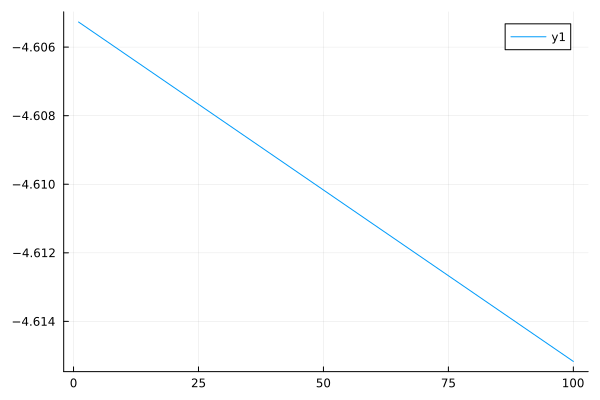

0.0009064812480371541


Progress:  36%|██████████████▊                          |  ETA: 0:00:00

dt = 0.0011031667805212148


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


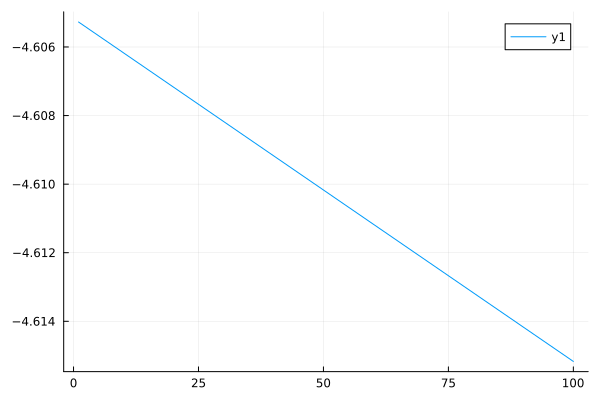

0.000468763568311028


Progress:  21%|████████▋                                |  ETA: 0:00:00

dt = 0.0021332715842296277


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


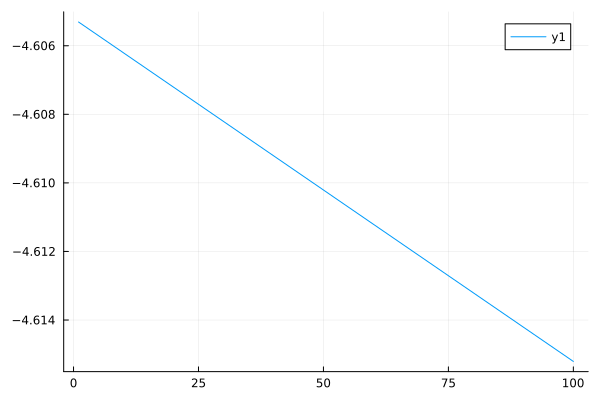

0.0002670496107046343


Progress:  16%|██████▌                                  |  ETA: 0:00:01

dt = 0.003744622571669026


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


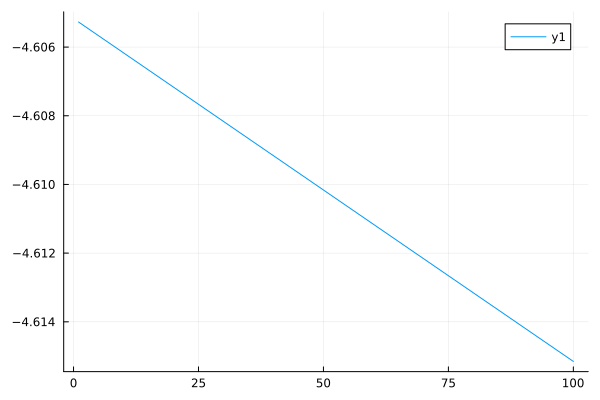

0.00016334770281641888


Progress:  12%|████▉                                    |  ETA: 0:00:01

dt = 0.006121910395788468


Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


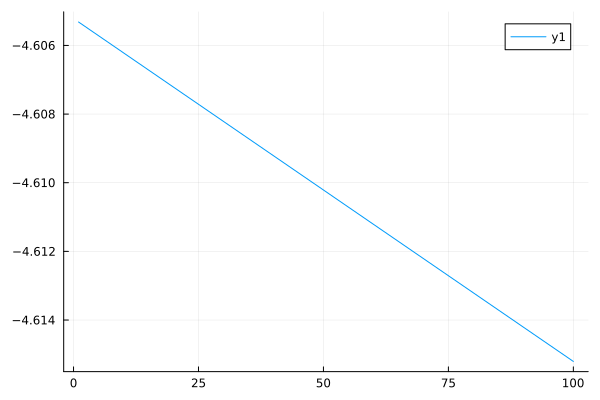

0.00010588676759665107


Progress:   9%|███▊                                     |  ETA: 0:00:01

dt = 0.009444050684493908


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


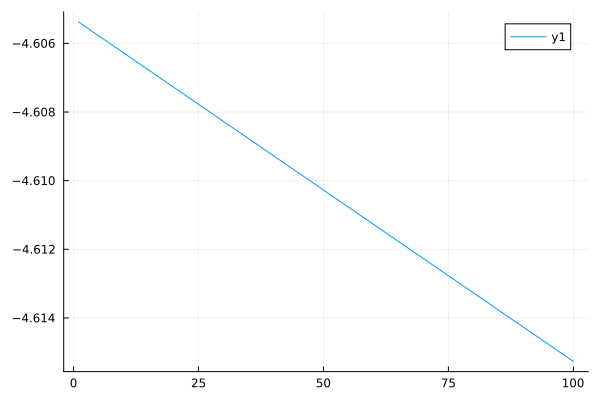

7.183278336262939e-5


Progress:   7%|██▉                                      |  ETA: 0:00:01

dt = 0.013921220272807143


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


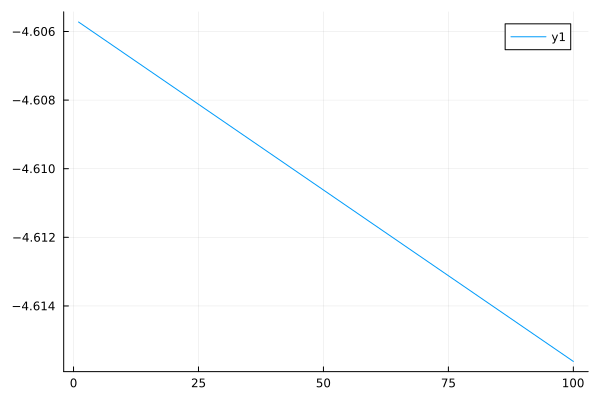

5.050529311600996e-5


Progress:   6%|██▌                                      |  ETA: 0:00:02

dt = 0.01979990488725635


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01


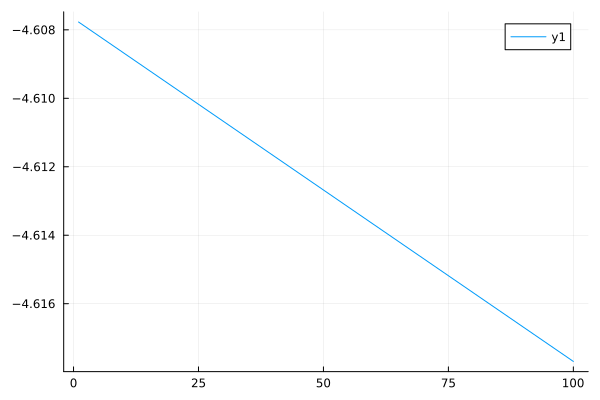

In [204]:
omega_list = []
for b in [0.6, 0.9, 1.2]
    omega_val = []
    for i = 100:50:500
        l = i / 100

        foldername = "../data/k01b"*b_to_string(b)
        filename = foldername*"/l"*string(i)*".npy"
        n = npzread(filename)

        filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
        sol = npzread(filename)

        system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
        coord = LambdaCoordinate(ST.w_project(n))

        push!( omega_val, omega(system,coord) )
    end
    push!(omega_list, omega_val)
end

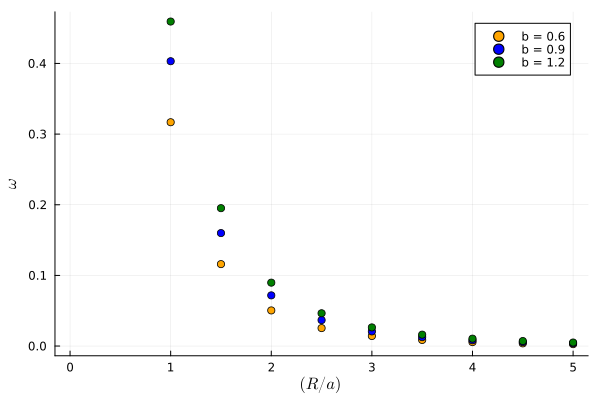

In [245]:
length_scale = [i/100 for i=100:50:500]
T = plot(xlabel=L"(R/a)", ylabel=L"\omega")
colour = [:orange, :blue, :green]
scatter!(T, length_scale, omega_list[1], label="b = 0.6", colour=colour[1])
scatter!(T, length_scale, omega_list[2], label="b = 0.9", colour=colour[2])
scatter!(T, length_scale, omega_list[3], label="b = 1.2", colour=colour[3])
plot!(T, [0], [0], label=false)

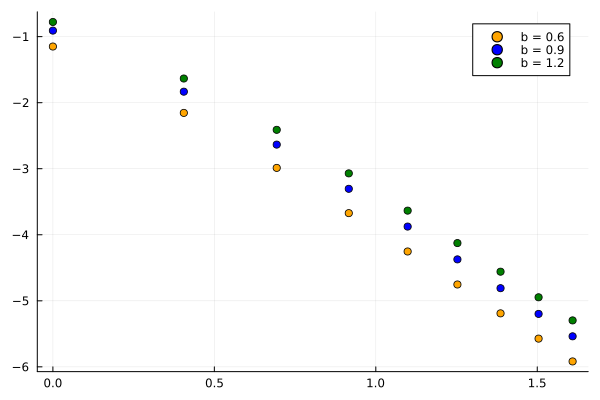

In [250]:
log_plot = plot()
scatter!(log_plot, log.(length_scale), log.(omega_list[1]), label="b = 0.6", colour=colour[1])
scatter!(log_plot, log.(length_scale), log.(omega_list[2]), label="b = 0.9", colour=colour[2])
scatter!(log_plot, log.(length_scale), log.(omega_list[3]), label="b = 1.2", colour=colour[3])
log_plot

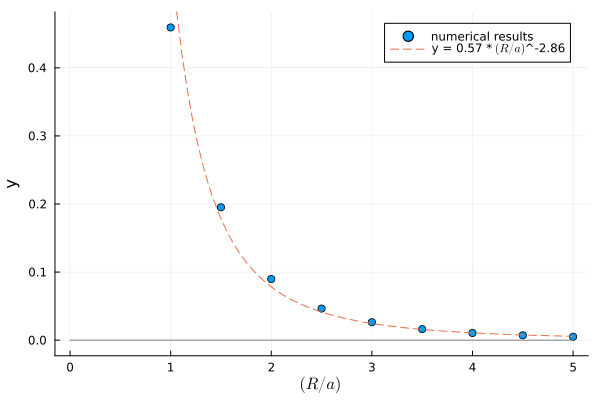

(0.569869914771346, -2.8642624547347406)

In [236]:
analyse_power_law(length_scale, omega_list[3])

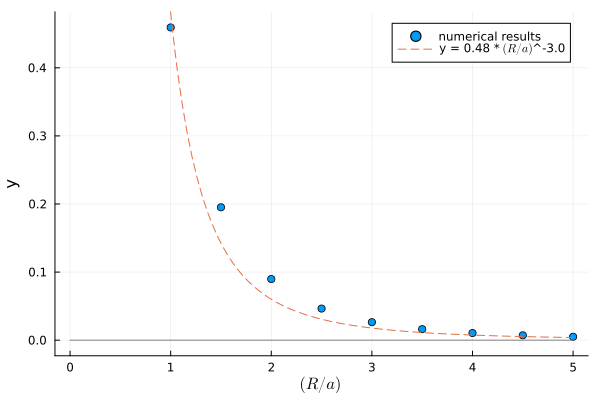

0.480166052229579

In [239]:
fit_power_law(length_scale, omega_list[3], power=-3)

In [238]:
prefactor

3-element Vector{Any}:
 0.3243100448402252
 0.41725694338782005
 0.480166052229579

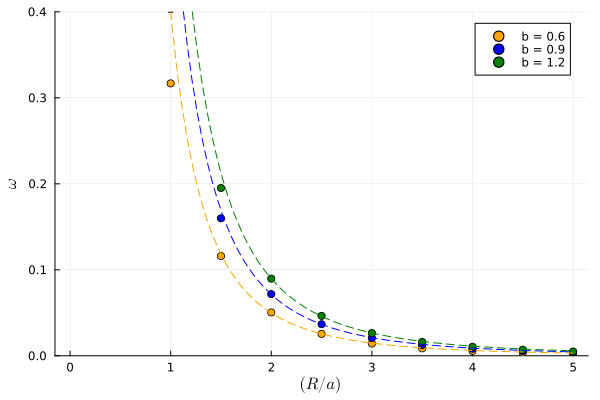

In [246]:
prefactor = []
for i=1:3
    push!(prefactor,fit_power_law(length_scale[3:1:end], omega_list[i][3:1:end], power=-3))
end
IJulia.clear_output()
l_range = LinRange(0,5,100)
for i=1:3
    plot!(T, l_range, prefactor[i]*l_range.^(-3), label=false, colour=colour[i], ls=:dash, ylims=(0,0.4))
end
T

## Plot

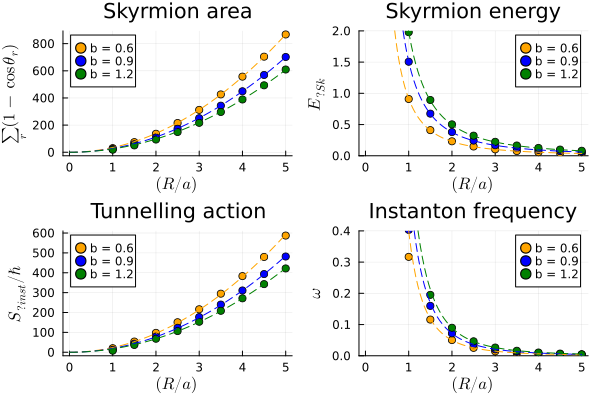

In [268]:
title!(S, "Skyrmion area")
title!(Q, "Skyrmion energy")
title!(P, "Tunnelling action")
title!(T, "Instanton frequency")
plot(S,Q,P,T)

In [270]:
savefig("Images/l0_scalings.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/l0_scalings.png"

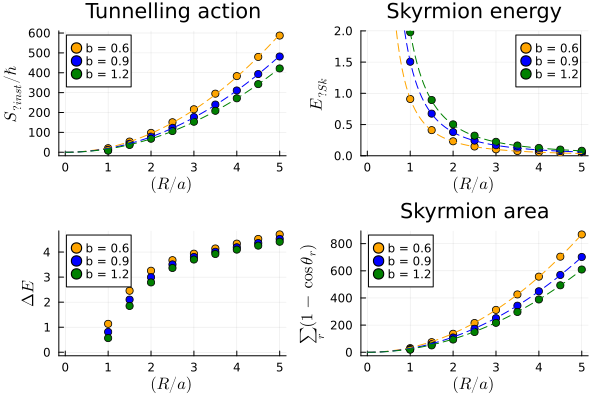

In [271]:
plot(P,Q,R,S)

In [134]:
savefig("Images/l0_scalings.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/Images/l0_scalings.png"

# Skyrmion scaling

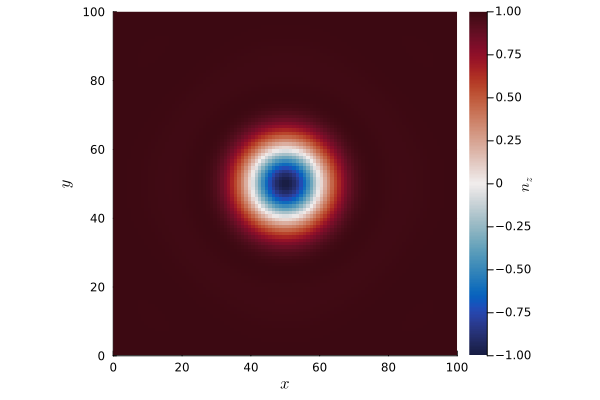

In [152]:
i = 500
l = i / 100
b = 0.6

foldername = "../data/k01b"*b_to_string(b)
filename = foldername*"/l"*string(i)*".npy"
n = npzread(filename)

filename = foldername*"/sol_l"*string(Int(100*l))*".npy"
sol = npzread(filename)

system = microscopic_system(length_scale=l, k=0.1, b=b, n_sites=n.size[2])
coord = LambdaCoordinate(ST.w_project(n))

P3 = show_nz_heatmap(n,system.lattice)

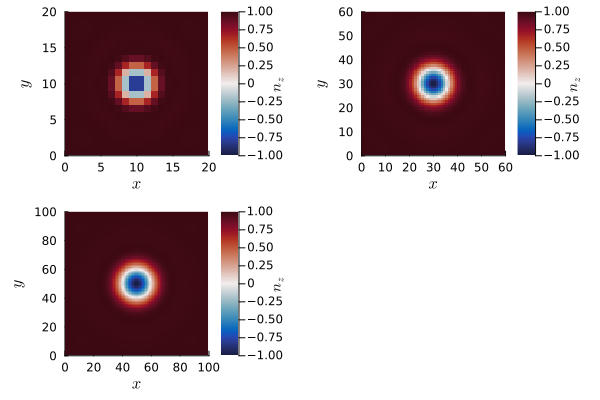

In [154]:
plot(P1,P2,P3)

In [ ]:
show_nz_heatmap()

# Phase portraits

In [5]:
length_scale = []
skyrmion = []
instanton_sol = []
for i = 200:50:500
    l = i / 100
    push!(length_scale, l)

    filename = "../data/k01b06/l"*string(i)*".npy"
    push!(skyrmion, npzread(filename))

    filename = "../data/k01b06/sol_l"*string(Int(100*l))*".npy"
    push!(instanton_sol, npzread(filename))
end

In [6]:
i = 1
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))

function reflect_xy(sol)
    sol_ref = similar(sol)
    sol_ref[1,:] .= sol[2,:]; sol_ref[2,:] .= sol[1,:]
    return sol_ref
end

function direction_vector(angle)
    return (cos(pi*angle/180), sin(pi*angle/180))
end

function phase_portrait(system, coord; xmin=-1.3, xmax=1.3, instanton, T=30, dt=0.05)
    P = plot(aspect_ratio=:equal, xlims=(xmin,xmax),ylims=(xmin,xmax), xlabel=L"\lambda", ylabel=L"\bar{\lambda}")

    sol_list = [instanton]
    colour_list = [:orange]

    push!(sol_list, reflect_xy(instanton))
    push!(colour_list, :orange)

    i = argmin(abs2.(instanton[1,:]+instanton[2,:]))
    d0 = abs(instanton[1,i])

    # add cycles in the region D
    for (x0,y0) in ( (-d0/3,d0/3), (-d0*2/3,d0*2/3))
        sol = solve_ivp([x0,y0], system,coord, dt=dt,T=T)
        push!(sol_list, sol)
        push!(colour_list, :lightblue)
    end

    # add open solutions
    for (x0,y0) in ( (1.1, 1.1), (-1.1,-1.1), (d0+0.1,-d0-0.1) )
        sol1 = solve_ivp([x0,y0], system,coord, dt=dt,T=T)
        sol2 = solve_ivp(sol1[:,1], system,coord, dt=-dt,T=T)
        sol = hcat(sol2[:,end:-1:1], sol1)
        push!(sol_list, sol)
        push!(colour_list, :lightblue)

        push!(sol_list, reflect_xy(sol))
        push!(colour_list, :lightblue)
    end

    IJulia.clear_output()

    for i=1:length(sol_list)
        sol = sol_list[i]
        ST.plot_sol!(P, sol; system=system, coord=coord, xmin=xmin,xmax=xmax, colour=colour_list[i])
    end
    return P
end

phase_portrait (generic function with 1 method)

In [7]:
length_scale[7]

5.0

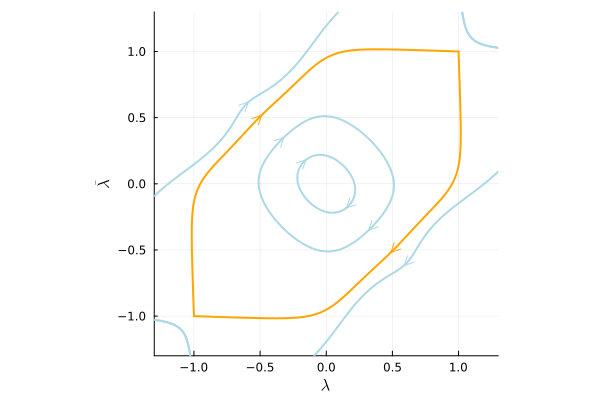

TypeError: TypeError: in typeassert, expected REPL.REPLCompletions.MethodCompletion, got a value of type REPL.REPLCompletions.TextCompletion

In [9]:
i = 1
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=0.1, b=0.6, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P1 = phase_portrait(system,coord, instanton=instanton_sol[i], T=30, dt=0.05)

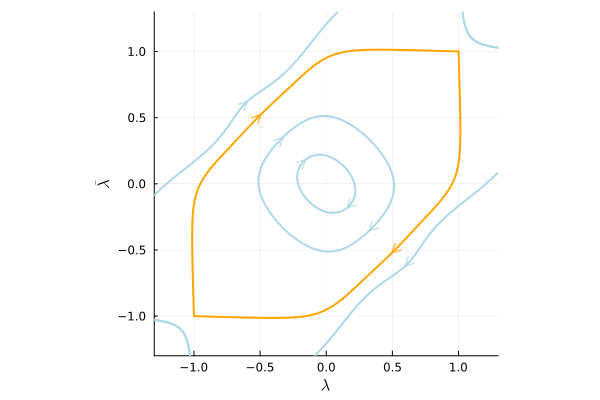

In [27]:
i = 7
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P2 = phase_portrait(system,coord, instanton=instanton_sol[i], T=30, dt=0.05)

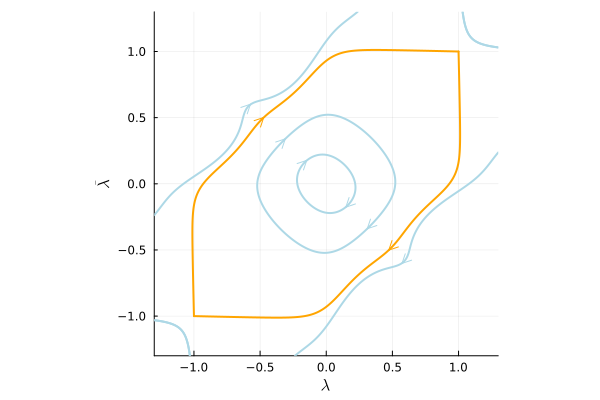

In [28]:
i = 13
xmin, xmax = -1.3, 1.3
system = microscopic_system(length_scale=length_scale[i], k=2.6, b=4.0, n_sites=skyrmion[i].size[2])
coord = LambdaCoordinate(ST.w_project(skyrmion[i]))
P3 = phase_portrait(system,coord, instanton=instanton_sol[i], T=100, dt=0.1)

i = 2085, 	, j=3986
i = 3117, 	, j=11036
i = 9272, 	, j=32763


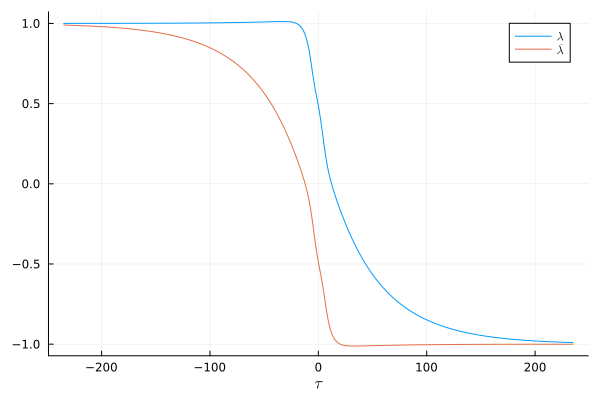

In [37]:
function distance_squared(x1,y1,x2,y2)
    return abs2(x1-x2)+abs2(y1-y2)
end

function show_instanton(sol; dt=0.02, epsilon=0.01)
    centre = argmin( abs2.(sol[1,:]+sol[2,:]) )

    i = centre
    while distance_squared(sol[1,i],sol[2,i], 1,1) > epsilon^2
        i = i-1
    end

    j = centre
    while distance_squared(sol[1,j],sol[2,j], -1,-1) > epsilon^2
        j = j+1
    end
    println("i = $i, \t, j=$j")
    T = dt*(j-i)
    t = LinRange(-T/2, T/2, j-i+1)

    P = plot(xlabel=L"\tau")
    plot!(P, t, real.(sol[1,i:1:j]), label=L"\lambda")
    plot!(P, t, real.(sol[2,i:1:j]), label=L"\bar{\lambda}")
    return P
end
Q1 = show_instanton(instanton_sol[1])
Q2 = show_instanton(instanton_sol[7])
Q3 = show_instanton(instanton_sol[13])

In [39]:
title=["a1", "a2", "b1", "b2", "c1", "c2"]
title!(P1,"a1)"); title!(P2,"a2)"); title!(P3,"a3)");
title!(Q1,"b1)"); title!(Q2,"b2)"); title!(Q3,"b3)");

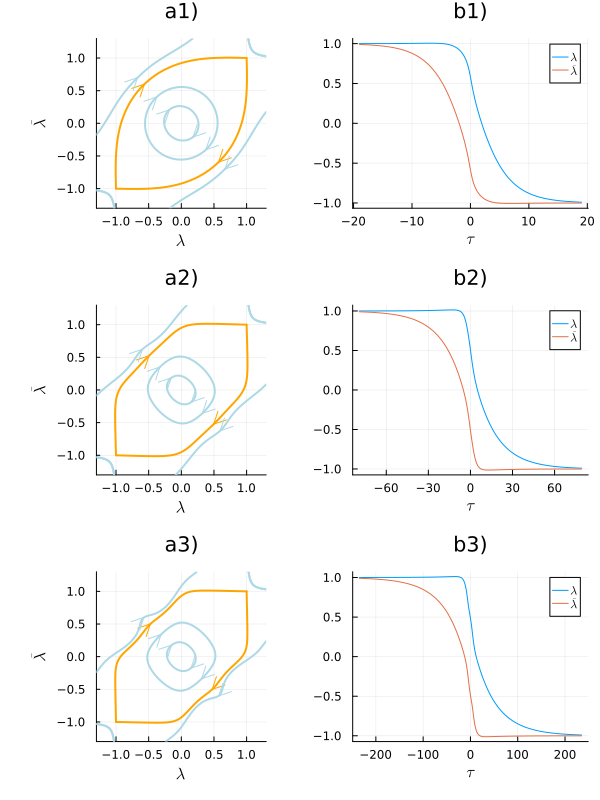

In [40]:
l = @layout [a b ; c d ; e f]
plot(P1,Q1,P2,Q2,P3,Q3, size = (600,800), layout=l)

In [41]:
savefig("phase_portraits_and_instantons.png")

"/home/jan/Documents/GitHub/skyrmion-tunnelling/notebooks/phase_portraits_and_instantons.png"

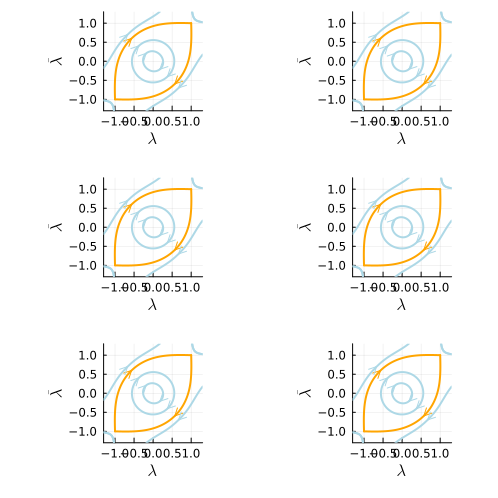

In [86]:
plot(P1,P1,P1,P1,P1,P1, layout = @layout [a b ; c d ; e f])

In [ ]:
n = skyrmion[1]
in_plane_quiver(n,system.lattice)